In [77]:
import gamry_parser
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
from pathlib import Path
from matplotlib.ticker import MultipleLocator
from scipy.interpolate import make_splrep
import math
from scipy.signal import savgol_filter

main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\EIS_data\inhibitors")
file_list = list(main_dir.rglob('*_1H.DTA'))

all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    header_data = parser.get_header()
    data = parser.curves[0]
    eis_data = {
        'name':str(filename).split("\\")[-1],
        'Pt': data.index.values,
        'Zreal':data['Zreal'].values*header_data.get('AREA'),
        'Zimag':-data['Zimag'].values*header_data.get('AREA'),
        'Zmod':data['Zmod'].values*header_data.get('AREA'),
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values
    }

    eis_data_clean = {
        'name':str(filename).split("\\")[-1],
        'Pt': data.index.values,
        'Zreal':data['Zreal'].values*header_data.get('AREA'),
        'Zimag':data['Zimag'].values*header_data.get('AREA'),
        'Zmod':data['Zmod'].values*header_data.get('AREA'),
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values
    }
    

    gaps = np.where(np.diff(eis_data['Pt']) != 1)[0]
  
    if len(gaps) > 0:
        for idx in reversed(gaps):
            num_missing = int(np.diff(eis_data['Pt'])[idx] - 1)
        
            # Define start and end anchors from the current state of clean data
            f_start, f_end = eis_data_clean['Freq'][idx], eis_data_clean['Freq'][idx+1]
            re_start, re_end = eis_data_clean['Zreal'][idx], eis_data_clean['Zreal'][idx+1]
            im_start, im_end = eis_data_clean['Zimag'][idx], eis_data_clean['Zimag'][idx+1]
            print(im_start,im_end)
            pt_start = eis_data_clean['Pt'][idx]
    
            # --- Generate the "Bridge" ---
            # Frequency: Geometric space (Logarithmic)
            f_bridge = np.geomspace(f_start, f_end, num_missing + 2)[1:-1]
            
            # Components: Linear space
            re_bridge = np.linspace(re_start, re_end, num_missing + 2)[1:-1]
            im_bridge = np.linspace(im_start, im_end, num_missing + 2)[1:-1]
            
            # Point numbers: Integers
            pt_bridge = np.arange(pt_start + 1, pt_start + 1 + num_missing)
    
            # --- Calculate Derived Values for the Bridge ---
            mod_bridge = np.sqrt(re_bridge**2 + im_bridge**2)
            # Degrees for Phase
            phz_bridge = np.degrees(np.arctan2(im_bridge, re_bridge))
    
            # --- Insert into eis_data_clean ---
            eis_data_clean['Freq'] = np.insert(eis_data_clean['Freq'], idx + 1, f_bridge)
            eis_data_clean['Zreal'] = np.insert(eis_data_clean['Zreal'], idx + 1, re_bridge)
            eis_data_clean['Zimag'] = np.insert(eis_data_clean['Zimag'], idx + 1, im_bridge)
            eis_data_clean['Zmod'] = np.insert(eis_data_clean['Zmod'], idx + 1, mod_bridge)
            eis_data_clean['Zphz'] = np.insert(eis_data_clean['Zphz'], idx + 1, phz_bridge)
            eis_data_clean['Pt'] = np.insert(eis_data_clean['Pt'], idx + 1, pt_bridge)
    
    print(f"Cleaned data created. Total points: {len(eis_data_clean['Pt'])}")
            
    eis_data_savgol = {
        'name':str(filename).split("\\")[-1],
        'Zreal':savgol_filter(np.flip(eis_data_clean['Zreal']),window_length=11, polyorder=3),
        'Zimag':-savgol_filter(np.flip(eis_data_clean['Zimag']),window_length=11, polyorder=3),
        'Zmod':savgol_filter(np.flip(eis_data_clean['Zmod']),window_length=11, polyorder=3),
        'Zphz':savgol_filter(np.flip(eis_data_clean['Zphz']),window_length=11, polyorder=3),
        'Freq':np.flip(eis_data_clean['Freq'])
    }
    
    all_datasets.append({"eis_data":eis_data,"eis_data_clean":eis_data_clean, "eis_data_savgol":eis_data_savgol})
    print(eis_data['name'])


Cleaned data created. Total points: 71
Cauvel_2_8HQ_1H.DTA
Cleaned data created. Total points: 71
Cauvel_3_BTA_1H.DTA
Cleaned data created. Total points: 69
Cauvel_1_Lcystine_1H.DTA
Cleaned data created. Total points: 67
Cauvel_1_MBT_1H.DTA
Cleaned data created. Total points: 66
Cauvel_3_Mo_1H.DTA
Cleaned data created. Total points: 69
Cauvel_4_NaCl_1H.DTA
Cleaned data created. Total points: 68
Cauvel_4_NaVO3_1H.DTA


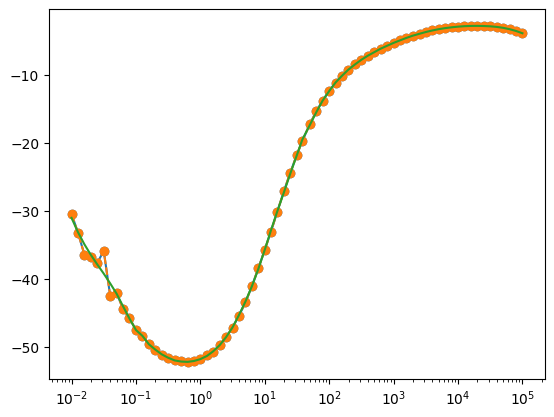

In [42]:
plt.semilogx(all_datasets[5]['eis_data']['Freq'],all_datasets[5]['eis_data']['Zphz'],'o-')
plt.semilogx(all_datasets[5]['eis_data_clean']['Freq'],all_datasets[5]['eis_data_clean']['Zphz'],'o--')
plt.semilogx(all_datasets[5]['eis_data_savgol']['Freq'],all_datasets[5]['eis_data_savgol']['Zphz'])

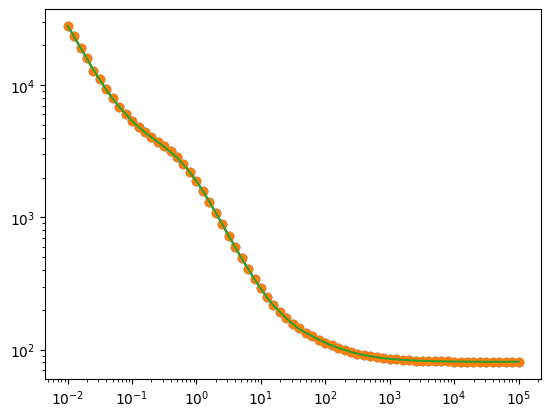

In [3]:
plt.loglog(all_datasets[0]['eis_data']['Freq'],all_datasets[0]['eis_data']['Zmod'],'o-')
plt.loglog(all_datasets[0]['eis_data_clean']['Freq'],all_datasets[0]['eis_data_clean']['Zmod'],'o--')
plt.loglog(all_datasets[0]['eis_data_savgol']['Freq'],all_datasets[0]['eis_data_savgol']['Zmod'])

In [40]:
print(all_datasets[5]['eis_data']['Zmod'])

[  44.62731238   44.75975625   44.91479153   45.10846697   45.33034638
   45.56743425   45.80123797   46.0508467    46.31510584   46.58688262
   46.86712636   47.15779987   47.4700449    47.79685696   48.14336113
   48.51921103   48.91926876   49.39221296   49.87328416   50.39520205
   50.99701732   51.62972418   52.35348942   53.05988454   53.90211033
   54.78693393   55.70214881   56.76491982   57.86078897   59.09985888
   60.42902502   62.06330981   63.80128287   65.96144965   68.98293778
   71.85503528   75.64554201   80.38152662   86.49871713   93.8908916
  102.46177037  112.8390635   125.94156511  141.80320718  161.22495189
  182.62097498  208.84695318  238.56266838  274.10840282  313.84387428
  363.25349583  419.45028865  479.69672867  551.31109686  633.04618345
  727.61449647  834.76074407  956.04746632 1091.98717126 1242.77934573
 1427.60295061 1618.24182168 1801.82424631 2002.17575369 2297.74983964
 2528.41436818 2729.84605516 3065.24823605 3280.00384862 3604.00192431
 3938.2

In [61]:
colors = ["r", "c", "m", "g", "b", "darkorange", "blueviolet", "y"]
markers = ['s', 'o', '^', 'd', 'p', '*', 'v', 'o']
label_formatter = {
    'NaVO3': r'NaVO$_3$',      
    'NaCl': 'NaCl',            
    '8HQ': '8HQ',              
    'BTA': 'BTA',
    'Lcystine': 'L-Cystine',   
    'MBT': 'MBT',
    'Mo': 'Na$_2$MoO$_4$'
}

In [12]:
colors = ["r", "c", "m", "g", "b", "darkorange", "blueviolet", "y"]
markers = ['s', 'o', '^', 'd', 'p', '*', 'v', 'o']
label_formatter = {
    'NaVO3(1)': r'NaVO$_3$ - 1',      
    'NaVO3(2)': r'NaVO$_3$ - 2',           
    'NaVO3(3)': r'NaVO$_3$ - 3',             
    'control': 'Control'
}

In [34]:
colors = ["r", "c", "m", "g", "b", "darkorange", "blueviolet", "y"]
markers = ['s', 'o', '^', 'd', 'p', '*', 'v', 'o']
label_formatter = {
    'NaVO3(1)': r'NaVO$_3$ - 1',      
    'NaVO3(2)': r'NaVO$_3$ - 2',                        
    'control': 'Control',
    'MBT(1)': 'MBT - 1',      
    'MBT(2)': 'MBT - 2',
}

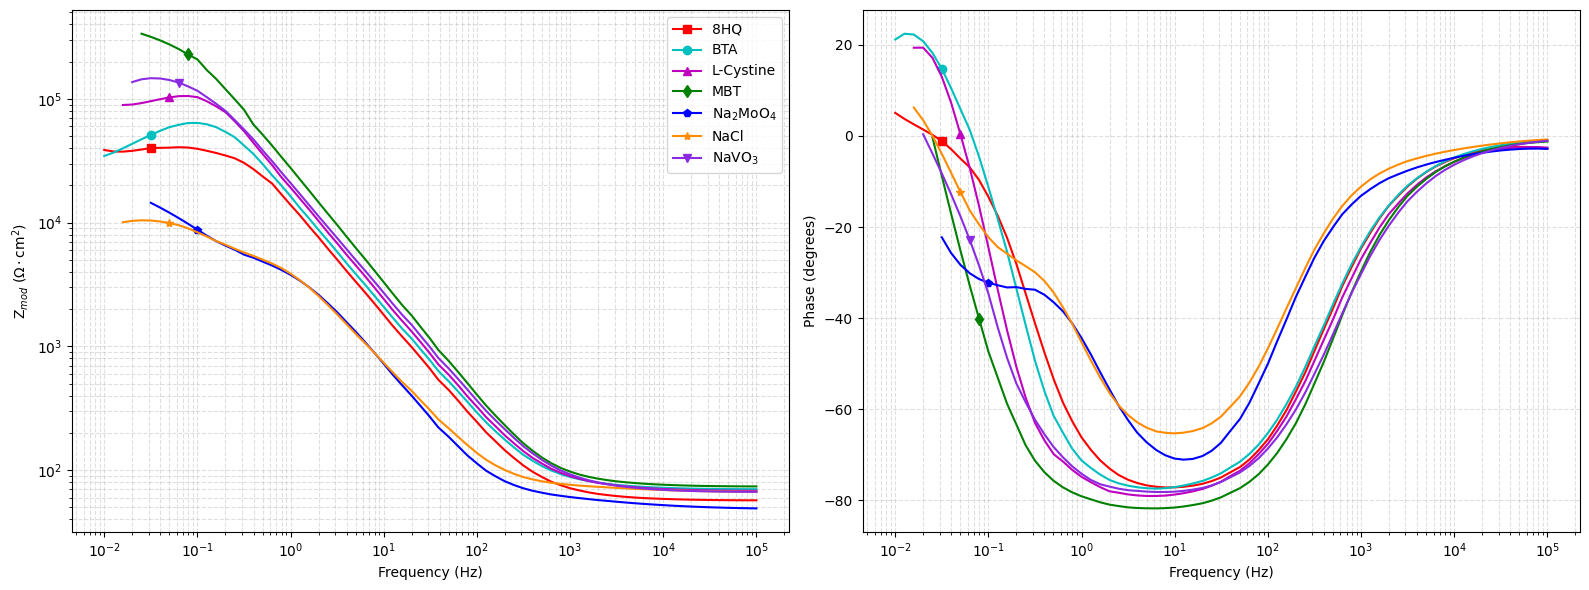

In [79]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize = (16,6))

for i, dataset in enumerate(all_datasets):
    #ax1.loglog(dataset['eis_data']['Freq'],dataset['eis_data']['Zmod'],label = dataset['eis_data_filtered']['name'])
    raw_name = dataset['eis_data_savgol']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax1.loglog(
        dataset['eis_data_savgol']['Freq'],
        dataset['eis_data_savgol']['Zmod'],
        label=label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         
        markersize=6,          
        markevery=(5,70)
    )
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel(r'Z$_{mod}$ ($\Omega\cdot$cm$^2$)')
    ax1.grid(True, which="both", linestyle='--', alpha=0.4)
    ax1.legend()

for i, dataset in enumerate(all_datasets):
    #ax2.semilogx(dataset['eis_data']['Freq'],dataset['eis_data']['Zphz'],label = dataset['eis_data_filtered']['name'])
    ax2.semilogx(
        dataset['eis_data_savgol']['Freq'],
        dataset['eis_data_savgol']['Zphz'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,70)
    )
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Phase (degrees)')
    ax2.grid(True, which="both", linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('bode_1H_inhibitors.pdf', bbox_inches='tight')
plt.show()

[np.float64(10449.986719930075), np.float64(13370.472667482516), np.float64(40375.50323426584), np.float64(63611.93068764584), np.float64(103497.4639370632), np.float64(146525.79941025644), np.float64(339254.71551048954)]


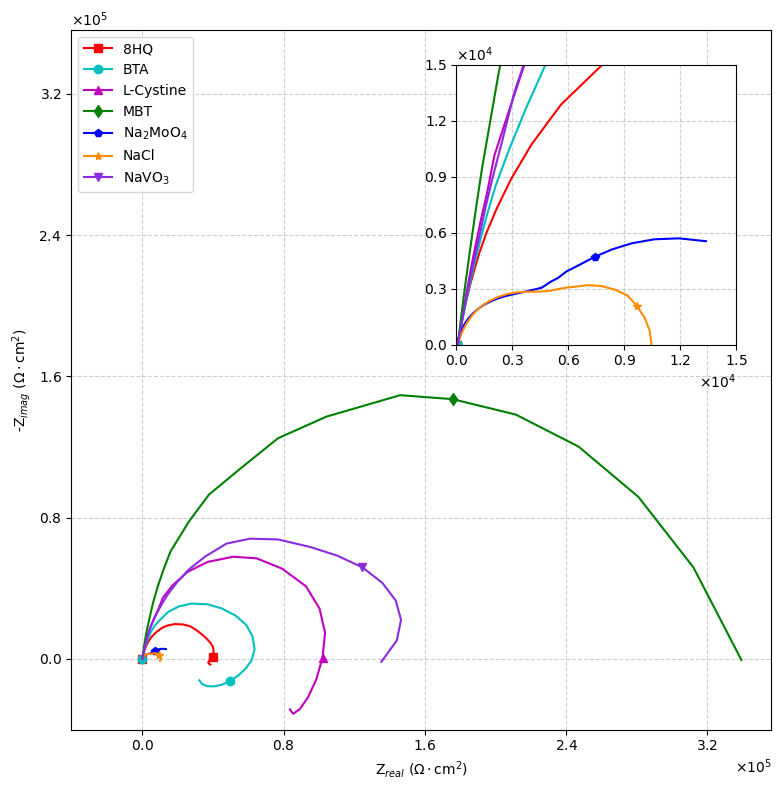

In [86]:
fig2, ax3 = plt.subplots(figsize=(8, 8))
axins = ax3.inset_axes([0.55, 0.55, 0.4, 0.4])
Max_Zreals = []
Max_Zimags = []

main_step = 0.8e5
inset_step = 3000

for i, dataset in enumerate(all_datasets):
    raw_name = dataset['eis_data_savgol']['name'].split('_')[2]
    label = label_formatter.get(raw_name)
    ax3.plot(
        dataset['eis_data_savgol']['Zreal'],
        dataset['eis_data_savgol']['Zimag'],
        label = label,
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,65)
    )
    ax3.legend(loc = 'upper left')
    ax3.xaxis.set_major_locator(MultipleLocator(main_step))
    ax3.yaxis.set_major_locator(MultipleLocator(main_step))
    ax3.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    
    axins.plot(
        dataset['eis_data_savgol']['Zreal'],
        dataset['eis_data_savgol']['Zimag'],
        label = dataset['eis_data_savgol']['name'],
        color=colors[i % len(colors)],      
        marker=markers[i % len(markers)],
        linewidth=1.5,         # Line thickness
        markersize=6,          # Size of the symbol
        markevery=(5,65)
    )
    axins.xaxis.set_major_locator(MultipleLocator(inset_step))
    axins.yaxis.set_major_locator(MultipleLocator(inset_step))
    axins.ticklabel_format(style='sci', axis='both', scilimits=(0,0), useMathText=True)
    axins.grid(True, linestyle='--', alpha=0.6)
    
    max_Zreals = dataset['eis_data_savgol']['Zreal'].max()
    max_Zimags = dataset['eis_data_savgol']['Zimag'].max()
    Max_Zreals.append(max_Zreals)
    Max_Zimags.append(max_Zimags)


ax3.set_aspect('equal')
ax3.set_xlabel(r'Z$_{real}$ ($\Omega\cdot$cm$^2$)')
ax3.set_ylabel(r'-Z$_{imag}$ ($\Omega\cdot$cm$^2$)')
ax3.grid(True, linestyle='--', alpha=0.6)


Max_Zreals.sort()
print(Max_Zreals)

axins.set_xlim(0, 15000)
axins.set_ylim(0, 15000)
#print(overall_min_inset,overall_max_inset)

x_min, x_max = ax3.get_xlim()
y_min, y_max = ax3.get_ylim()
overall_min = min(x_min, y_min)
overall_max = max(x_max, y_max)
ax3.set_xlim(overall_min, overall_max)
ax3.set_ylim(overall_min, overall_max)

plt.tight_layout()
plt.savefig('nyquist_1H_inhibitors.pdf', bbox_inches='tight')
plt.show()

